# TCLab – Grundversuch zur Fault Detection mit Heizleistungsprofilen und Baseline-Anomalieerkennung

## Einführung

In diesem Grundversuch arbeiten wir mit dem **Temperature Control Laboratory (TCLab)** und fahren
vorgegebene **Heizleistungsprofile** für beide Heizer ab.

Ziele dieses Notebooks:

- Heizleistungsprofile für beide Heizer systematisch vorgeben
- Temperaturverläufe für beide Sensoren aufzeichnen
- **Normalverhalten (NOC)** und **anomaliebehaftetes Verhalten** vergleichen
- Residuen als Grundlage für **Fault Detection** und **Anomaly Detection** verwenden
- einfache Baseline-Methoden zur Anomalieerkennung anwenden

Bei der ersten Verwendung nutzen wir die folgenden Fachbegriffe:

- **MV (Manipulated Variable, Stellgröße):** $Q_1(t)$ und $Q_2(t)$
- **PV (Process Value, Prozesswert):** $T_1(t)$ und $T_2(t)$
- **Störgröße:** z. B. Luftzug, Pusten oder kurze Berührung
- **Residuum:** Abweichung des Störversuchs vom Normalversuch bei identischem Heizleistungsprofil


## Versuchsprinzip und Messidee

Im Versuch werden zwei Heizleistungen vorgegeben:

$$
Q_1(t), \quad Q_2(t)
$$

und zwei Temperaturen gemessen:

$$
T_1(t), \quad T_2(t)
$$

Im **Normalversuch** wird das Heizleistungsprofil ohne gezielte Störung gefahren.  
Im **Störversuch** wird **dasselbe Heizleistungsprofil** erneut gefahren, aber mit einer äußeren Störung.

Die Residuen werden anschließend aus dem Vergleich zwischen Referenzverlauf und Störversuch gebildet:

$$
e_1(t) = T_{1,\mathrm{ref}}(t) - T_1(t)
$$

$$
e_2(t) = T_{2,\mathrm{ref}}(t) - T_2(t)
$$

Zusätzlich betrachten wir die Betragsresiduen

$$
|e_1(t)|, \quad |e_2(t)|
$$

als einfache Alarmgrößen.


In [9]:
# Benötigte Pakete:
# !pip install tclab
# !pip install process-improvement

from pathlib import Path
from datetime import datetime
import time
import inspect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, clear_output
except ImportError as exc:
    raise ImportError(
        "Dieses Notebook ist für Jupyter ausgelegt und benötigt IPython.display."
    ) from exc

try:
    from tclab import TCLab, TCLabModel, clock
except ImportError as exc:
    raise ImportError(
        "Das Paket 'tclab' fehlt. Bitte zuerst mit 'pip install tclab' installieren."
    ) from exc

try:
    from process_improvement.charts.xmr_charts import xmr_chart
    from process_improvement.charts.utils import XmRChartConfig
except ImportError as exc:
    raise ImportError(
        "Das Paket 'process-improvement' fehlt. Bitte zuerst mit "
        "'pip install process-improvement' installieren."
    ) from exc

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True


def piecewise_profile(t, segments):
    """
    Gibt für die Zeit t den zugehörigen Wert eines stückweise konstanten Profils zurück.

    segments: Liste von Tupeln (t_end, value)
              Beispiel: [(60, 0), (140, 50), (210, 40)]
    """
    for t_end, value in segments:
        if t < t_end:
            return float(value)
    return float(segments[-1][1])


def update_live_run_plot(df, run_title):
    """
    Aktualisiert eine Live-Grafik für Heizleistungen und Temperaturen.
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(df["t"], df["Q1"], label="Q1 (MV)")
    axes[0].plot(df["t"], df["Q2"], label="Q2 (MV)")
    axes[0].set_ylabel("Heizleistung [%]")
    axes[0].set_title(f"{run_title} – Heizleistungsverläufe")
    axes[0].legend(loc="upper right")

    axes[1].plot(df["t"], df["T1"], label="T1 (PV)")
    axes[1].plot(df["t"], df["T2"], label="T2 (PV)")
    axes[1].set_xlabel("Zeit [s]")
    axes[1].set_ylabel("Temperatur [°C]")
    axes[1].set_title(f"{run_title} – Temperaturverläufe")
    axes[1].legend(loc="upper left")

    plt.tight_layout()
    clear_output(wait=True)
    display(fig)
    plt.close(fig)


def build_residuals(df_ref, df_test):
    """
    Bildet Residuen des Testlaufs gegen den Referenzlauf.
    """
    ref = df_ref[["t", "T1", "T2"]].copy()
    ref["t_round"] = ref["t"].round(1)
    ref = ref.rename(columns={"T1": "T1_ref", "T2": "T2_ref"})

    test = df_test.copy()
    test["t_round"] = test["t"].round(1)

    merged = test.merge(ref[["t_round", "T1_ref", "T2_ref"]], on="t_round", how="inner")

    merged["e1"] = merged["T1_ref"] - merged["T1"]
    merged["e2"] = merged["T2_ref"] - merged["T2"]
    merged["abs_e1"] = merged["e1"].abs()
    merged["abs_e2"] = merged["e2"].abs()

    return merged


def mean_std_center_sigma(series):
    """
    Einfache Lage- und Streuungsmaße für die Lehre:
    Mittelwert als Mittelpunkt, Standardabweichung als Sigma-Maß.
    """
    s = pd.Series(series).dropna()

    if len(s) == 0:
        return 0.0, 1.0

    center = float(s.mean())
    sigma = float(s.std(ddof=1))

    if (not np.isfinite(sigma)) or sigma < 1e-9:
        sigma = 1.0

    return center, sigma


def add_baseline_detection_features(
    df,
    rolling_window=15,
    threshold_sigma=3.0,
):
    """
    Ergänzt Baseline-Detektionsgrößen ohne festen Störbeginn.
    Die Kennwerte werden einfach über Mittelwert und Standardabweichung bestimmt.
    """
    out = df.copy()

    abs_e1_center, abs_e1_sigma = mean_std_center_sigma(out["abs_e1"])
    abs_e2_center, abs_e2_sigma = mean_std_center_sigma(out["abs_e2"])

    out["thr_abs_e1"] = abs_e1_center + threshold_sigma * abs_e1_sigma
    out["thr_abs_e2"] = abs_e2_center + threshold_sigma * abs_e2_sigma

    out["alarm_thr_e1"] = out["abs_e1"] > out["thr_abs_e1"]
    out["alarm_thr_e2"] = out["abs_e2"] > out["thr_abs_e2"]

    out["e1_roll_mean"] = out["e1"].rolling(window=rolling_window, min_periods=rolling_window).mean()
    out["e2_roll_mean"] = out["e2"].rolling(window=rolling_window, min_periods=rolling_window).mean()

    alarm_cols = ["alarm_thr_e1", "alarm_thr_e2"]
    out["alarm_any"] = out[alarm_cols].any(axis=1)

    stats = {
        "rolling_window": rolling_window,
        "threshold_sigma": threshold_sigma,
        "abs_e1_center": abs_e1_center,
        "abs_e1_sigma": abs_e1_sigma,
        "abs_e2_center": abs_e2_center,
        "abs_e2_sigma": abs_e2_sigma,
        "thr_abs_e1": float(out["thr_abs_e1"].iloc[0]),
        "thr_abs_e2": float(out["thr_abs_e2"].iloc[0]),
    }

    return out, stats


def plot_detection_results(df, stats):
    """
    Grafische Auswertung der Baseline-Detektion.
    """
    fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

    axes[0].plot(df["t"], df["T1"], label="T1")
    axes[0].plot(df["t"], df["T2"], label="T2")
    axes[0].set_ylabel("Temperatur [°C]")
    axes[0].set_title("Temperaturverläufe des Störversuchs")
    axes[0].legend(loc="upper left")

    axes[1].plot(df["t"], df["e1"], label="e1 = T1_ref - T1")
    axes[1].plot(df["t"], df["e2"], label="e2 = T2_ref - T2")
    axes[1].plot(df["t"], df["e1_roll_mean"], linestyle="--", label="roll. Mittelwert e1")
    axes[1].plot(df["t"], df["e2_roll_mean"], linestyle="--", label="roll. Mittelwert e2")
    axes[1].axhline(0, linestyle=":", color="black")
    axes[1].set_ylabel("Residuum [°C]")
    axes[1].set_title("Residuen mit rollendem Mittelwert")
    axes[1].legend(loc="upper left")

    axes[2].plot(df["t"], df["abs_e1"], label="|e1|")
    axes[2].plot(df["t"], df["abs_e2"], label="|e2|")
    axes[2].axhline(stats["thr_abs_e1"], linestyle="--", label="Schwelle |e1|")
    axes[2].axhline(stats["thr_abs_e2"], linestyle="--", label="Schwelle |e2|")
    axes[2].set_xlabel("Zeit [s]")
    axes[2].set_ylabel("Betragsresiduum [°C]")
    axes[2].set_title("Betragsresiduen mit Schwellenwerten")
    axes[2].legend(loc="upper left")

    plt.tight_layout()
    plt.show()


def _build_xmr_config(ylabel):
    """
    Erstellt eine XmRChartConfig möglichst kompatibel zu verschiedenen
    Versionen der Bibliothek process-improvement.
    """
    try:
        config_sig = inspect.signature(XmRChartConfig)
        config_params = set(config_sig.parameters)
    except Exception:
        config_params = set()

    config_kwargs = {}
    base_options = {
        "show": True,
        "show_label_values": False,
        "show_mean": True,
    }

    for key, value in base_options.items():
        if (not config_params) or (key in config_params):
            config_kwargs[key] = value

    ylabel_candidates = [
        "limit_chart_ylabel",
        "x_chart_ylabel",
        "ylabel",
        "value_ylabel",
    ]
    for key in ylabel_candidates:
        if config_params and key in config_params:
            config_kwargs[key] = ylabel
            break

    try:
        config = XmRChartConfig(**config_kwargs)
    except TypeError:
        config = XmRChartConfig()

    for key, value in base_options.items():
        if hasattr(config, key):
            try:
                setattr(config, key, value)
            except Exception:
                pass

    for key in ylabel_candidates:
        if hasattr(config, key):
            try:
                setattr(config, key, ylabel)
                break
            except Exception:
                pass

    return config


def run_xmr_chart(df, value_col, ylabel):
    """
    Erstellt eine XmR-Kontrollkarte mit process-improvement.
    """
    chart_df = df[["t", value_col]].copy()
    chart_df["t_label"] = chart_df["t"].round(0).astype(int).astype(str)

    config = _build_xmr_config(ylabel)

    try:
        chart_sig = inspect.signature(xmr_chart)
        chart_params = set(chart_sig.parameters)
    except Exception:
        chart_params = set()

    kwargs = {}
    if (not chart_params) or ("df" in chart_params):
        kwargs["df"] = chart_df

    if (not chart_params) or ("values" in chart_params):
        kwargs["values"] = value_col
    elif "value" in chart_params:
        kwargs["value"] = value_col

    if (not chart_params) or ("x_labels" in chart_params):
        kwargs["x_labels"] = "t_label"
    elif "x" in chart_params:
        kwargs["x"] = "t_label"

    if (not chart_params) or ("config" in chart_params):
        kwargs["config"] = config
    elif "chart_config" in chart_params:
        kwargs["chart_config"] = config

    try:
        return xmr_chart(**kwargs)
    except TypeError:
        fallback_kwargs = {
            k: v for k, v in kwargs.items()
            if k not in {"config", "chart_config"}
        }
        return xmr_chart(**fallback_kwargs)

## Sichere Nutzung des TCLab und Heizleistungsprofile

Das Notebook verwendet bevorzugt das reale **TCLab**.  
Falls keine Hardware erkannt wird, wird automatisch auf **`TCLabModel()`** gewechselt.

Wichtig:

- Beide Heizer werden verwendet.
- Nach jedem Versuch werden beide Heizleistungen auf null gesetzt.
- Die Verbindung wird nach jedem Versuch sauber geschlossen.

Für den Grundversuch verwenden wir ein einfaches, aber gut sichtbares Heizleistungsprofil:

- Start bei \(0\,\%\)
- mittlere Heizphase
- abgesenkte Phase
- hohe Heizphase
- Rückkehr auf \(0\,\%\)

Für \(Q_2\) wird ein ähnliches, aber nicht identisches Profil genutzt.

**Wichtiger Hinweis für den Vergleich Normalversuch / Störversuch:**  
Vor dem Störversuch sollten die Starttemperaturen wieder ungefähr auf dem Niveau des Normalversuchs liegen.
Dadurch wird der Vergleich zwischen Referenzlauf und Störlauf sauberer.


In [12]:

# ----------------------------
# Versuchsparameter
# ----------------------------
DT = 1.0
TOTAL_TIME = 360  # 6 Minuten
PLOT_UPDATE_EVERY = 5  # Live-Plot wird alle n Schritte aktualisiert

# ----------------------------
# Baseline-Detektion
# ----------------------------
ROLLING_WINDOW = 15
THRESHOLD_SIGMA = 3.0

# ----------------------------
# Heizleistungsprofile
# Studierende können diese Werte verändern.
# Format: (t_end, value)
# ----------------------------
Q1_SEGMENTS = [
    (20, 0),
    (140, 80),
    (210, 20),
    (300, 40),
    (360, 0),
]

Q2_SEGMENTS = [
    (10, 0),
    (140, 35),
    (210, 70),
    (300, 50),
    (360, 0),
]

print("Q1-Profil:", Q1_SEGMENTS)
print("Q2-Profil:", Q2_SEGMENTS)
print(f"Live-Plot-Aktualisierung: alle {PLOT_UPDATE_EVERY} Schritte")


Q1-Profil: [(20, 0), (140, 80), (210, 20), (300, 40), (360, 0)]
Q2-Profil: [(10, 0), (140, 35), (210, 70), (300, 50), (360, 0)]
Live-Plot-Aktualisierung: alle 5 Schritte


## Teil A – Normalversuch mit Live-Darstellung

Im folgenden Versuch wird das Heizleistungsprofil ohne gezielte Störung gefahren.


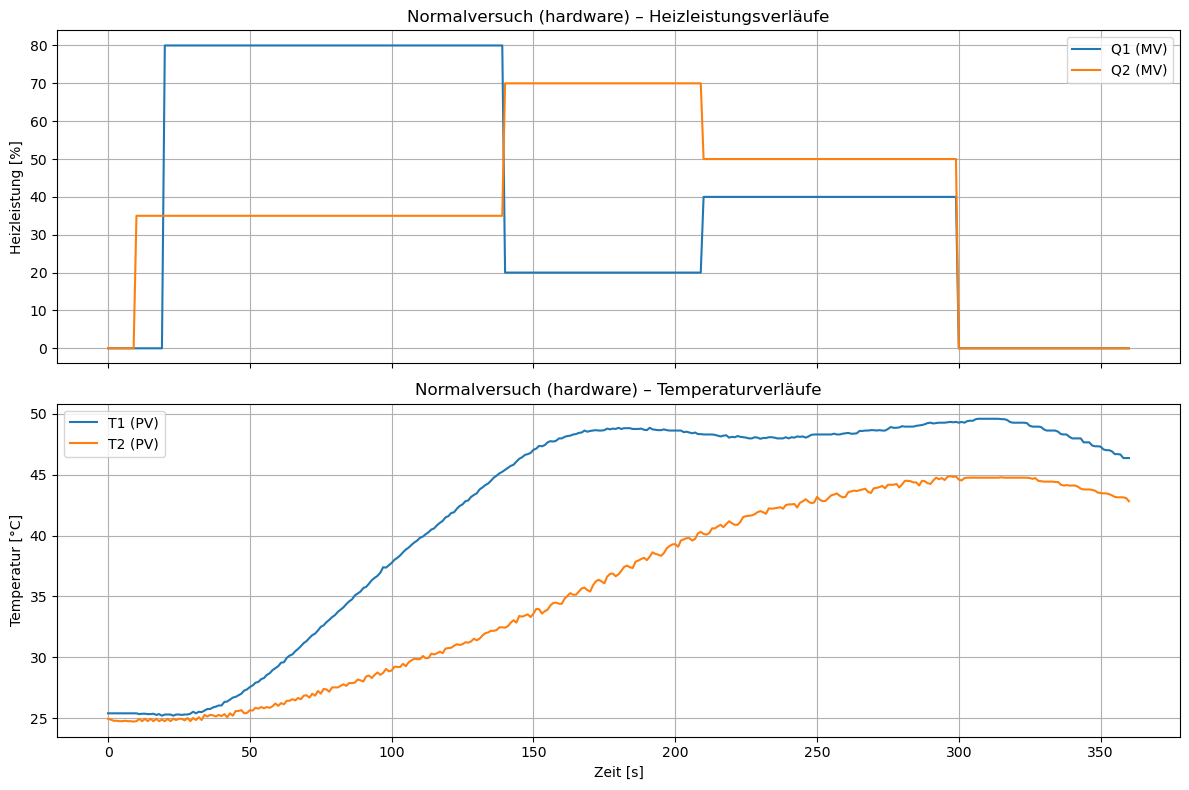

TCLab disconnected successfully.
Normalversuch abgeschlossen. Modus: hardware
Starttemperaturen: T1 = 25.41 °C, T2 = 24.93 °C


,run_name,mode,t,Q1,Q2,T1,T2
356,normal_run,hardware,356.00,0.0,0.0,46.680,43.135
357,normal_run,hardware,357.00,0.0,0.0,46.647,43.135
358,normal_run,hardware,358.01,0.0,0.0,46.357,43.135
359,normal_run,hardware,359.01,0.0,0.0,46.357,43.070
360,normal_run,hardware,360.00,0.0,0.0,46.357,42.813


In [15]:

# Teil A – Normalversuch mit Live-Darstellung

normal_rows = []
normal_df = None
normal_meta = {}
lab = None

try:
    try:
        lab = TCLab()
        mode = "hardware"
        print("Normalversuch: TCLab-Hardware verbunden.")
    except Exception as exc:
        print(f"Normalversuch: keine Hardware erkannt ({exc}). Wechsle auf TCLabModel().")
        lab = TCLabModel()
        mode = "model"

    start_T1 = float(lab.T1)
    start_T2 = float(lab.T2)

    for step, t in enumerate(clock(TOTAL_TIME, DT)):
        q1 = piecewise_profile(t, Q1_SEGMENTS)
        q2 = piecewise_profile(t, Q2_SEGMENTS)

        lab.Q1(q1)
        lab.Q2(q2)

        normal_rows.append(
            {
                "run_name": "normal_run",
                "mode": mode,
                "t": float(t),
                "Q1": float(lab.Q1()),
                "Q2": float(lab.Q2()),
                "T1": float(lab.T1),
                "T2": float(lab.T2),
            }
        )

        if (step % PLOT_UPDATE_EVERY == 0) or (t >= TOTAL_TIME - DT):
            live_df = pd.DataFrame(normal_rows)
            update_live_run_plot(live_df, run_title=f"Normalversuch ({mode})")

    normal_df = pd.DataFrame(normal_rows)
    normal_meta = {
        "run_name": "normal_run",
        "mode": mode,
        "start_T1": start_T1,
        "start_T2": start_T2,
        "total_time": TOTAL_TIME,
        "dt": DT,
    }

finally:
    if lab is not None:
        try:
            lab.Q1(0)
            lab.Q2(0)
            time.sleep(1)
        except Exception:
            pass

        try:
            lab.close()
        except Exception:
            pass

print(f"Normalversuch abgeschlossen. Modus: {normal_meta.get('mode', 'unbekannt')}")
print(f"Starttemperaturen: T1 = {normal_meta.get('start_T1', np.nan):.2f} °C, "
      f"T2 = {normal_meta.get('start_T2', np.nan):.2f} °C")

normal_df.tail()


## Teil B – Störversuch mit Live-Darstellung

Für den Störversuch wird **dasselbe Heizleistungsprofil** erneut gefahren. Achten SIe darauf, dass die Heizelemnte abgekühlt sind! Dazu sind mind. 5 min erforderlich.

Die Störung kann **jederzeit während der Messung** eingebracht werden, zum Beispiel durch:

- permanenter Luftzug
- Pusten
- kurze Berührung, auflegen einer Münze
- Abdecken mit einem Tuch

Auch hier werden Heizleistungen und Temperaturen **live dargestellt**, damit sich die Abweichungen
gegenüber dem Normalversuch direkt beobachten lassen.


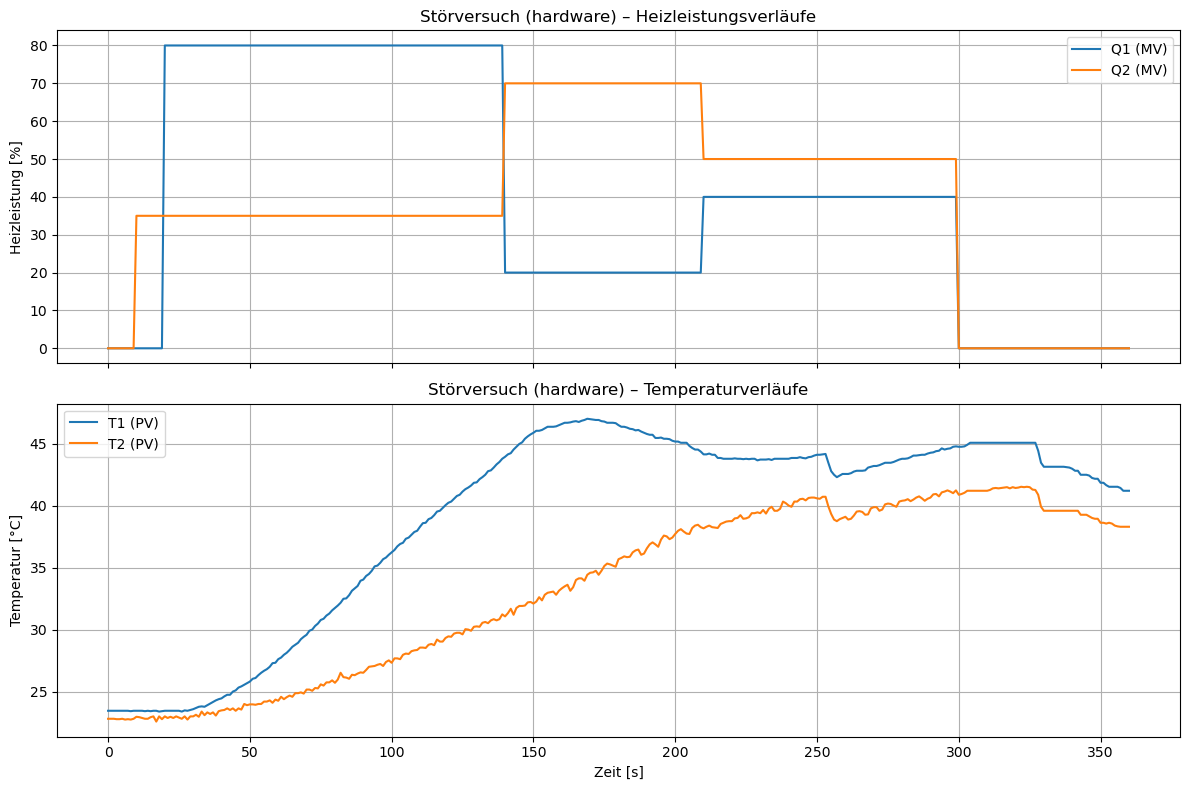

TCLab disconnected successfully.
Störversuch abgeschlossen. Modus: hardware
Starttemperaturen: T1 = 23.48 °C, T2 = 22.83 °C


,run_name,mode,t,Q1,Q2,T1,T2
355,disturbed_run,hardware,356.00,0.0,0.0,41.523,38.333
356,disturbed_run,hardware,357.01,0.0,0.0,41.427,38.301
357,disturbed_run,hardware,358.00,0.0,0.0,41.201,38.301
358,disturbed_run,hardware,359.00,0.0,0.0,41.201,38.301
359,disturbed_run,hardware,360.01,0.0,0.0,41.201,38.301


In [17]:

# Teil B – Störversuch mit Live-Darstellung

disturbed_rows = []
disturbed_df = None
disturbed_meta = {}
lab = None

try:
    try:
        lab = TCLab()
        mode = "hardware"
        print("Störversuch: TCLab-Hardware verbunden.")
    except Exception as exc:
        print(f"Störversuch: keine Hardware erkannt. Keine aktive Störung möglich")
        lab = TCLabModel()
        mode = "model"

    start_T1 = float(lab.T1)
    start_T2 = float(lab.T2)

    for step, t in enumerate(clock(TOTAL_TIME, DT)):
        q1 = piecewise_profile(t, Q1_SEGMENTS)
        q2 = piecewise_profile(t, Q2_SEGMENTS)

        lab.Q1(q1)
        lab.Q2(q2)

        disturbed_rows.append(
            {
                "run_name": "disturbed_run",
                "mode": mode,
                "t": float(t),
                "Q1": float(lab.Q1()),
                "Q2": float(lab.Q2()),
                "T1": float(lab.T1),
                "T2": float(lab.T2),
            }
        )

        if (step % PLOT_UPDATE_EVERY == 0) or (t >= TOTAL_TIME - DT):
            live_df = pd.DataFrame(disturbed_rows)
            update_live_run_plot(live_df, run_title=f"Störversuch ({mode})")

    disturbed_df = pd.DataFrame(disturbed_rows)
    disturbed_meta = {
        "run_name": "disturbed_run",
        "mode": mode,
        "start_T1": start_T1,
        "start_T2": start_T2,
        "total_time": TOTAL_TIME,
        "dt": DT,
    }

finally:
    if lab is not None:
        try:
            lab.Q1(0)
            lab.Q2(0)
            time.sleep(1)
        except Exception:
            pass

        try:
            lab.close()
        except Exception:
            pass

print(f"Störversuch abgeschlossen. Modus: {disturbed_meta.get('mode', 'unbekannt')}")
print(f"Starttemperaturen: T1 = {disturbed_meta.get('start_T1', np.nan):.2f} °C, "
      f"T2 = {disturbed_meta.get('start_T2', np.nan):.2f} °C")

disturbed_df.tail()


## Residuenbildung und Baseline-Anomalieerkennung

Der Normalversuch dient als Referenzlauf.

Für den Störversuch werden die Residuen berechnet als

$$
e_1(t) = T_{1,\mathrm{ref}}(t) - T_1(t)
$$

$$
e_2(t) = T_{2,\mathrm{ref}}(t) - T_2(t)
$$

Zusätzlich betrachten wir die Betragsresiduen

$$
|e_1(t)|,\quad |e_2(t)|
$$

als einfache Alarmgrößen.

Für die Baseline-Anomalieerkennung verwenden wir:

- Schwellenwerte auf den Betragsresiduen
- rollenden Mittelwert
- XmR-Kontrollkarten mit `process-improvement`

### Berechnung der Schwellen für \(|e_1|\) und \(|e_2|\)

Die Schwellen werden direkt aus den Betragsresiduen bestimmt. Für jedes Signal wird zuerst der Mittelwert berechnet:

$$
\mu = \mathrm{Mittelwert}(|e|)
$$

Als Sigma-Maß verwenden wir die Standardabweichung:

$$
\sigma = \mathrm{Std}(|e|)
$$

Mit der Drei-Sigma-Regel ergibt sich dann die Schwelle zu

$$
\text{Schwelle} = \mu + 3 \cdot \sigma
$$

Konkret also:

$$
\text{Schwelle}_{|e_1|} = \mathrm{Mittelwert}(|e_1|) + 3 \cdot \mathrm{Std}(|e_1|)
$$

$$
\text{Schwelle}_{|e_2|} = \mathrm{Mittelwert}(|e_2|) + 3 \cdot \mathrm{Std}(|e_2|)
$$



In [20]:

# Residuen bilden
residual_df = build_residuals(normal_df, disturbed_df)

# Baseline-Detektion ergänzen
residual_df, baseline_stats = add_baseline_detection_features(
    residual_df,
    rolling_window=ROLLING_WINDOW,
    threshold_sigma=THRESHOLD_SIGMA,
)

print("Kennwerte der Baseline-Detektion:")
for key, value in baseline_stats.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

residual_df.head(10)


Kennwerte der Baseline-Detektion:
rolling_window: 15
threshold_sigma: 3.0000
abs_e1_center: 3.0839
abs_e1_sigma: 1.5616
abs_e2_center: 2.4074
abs_e2_sigma: 1.1564
thr_abs_e1: 7.7688
thr_abs_e2: 5.8766


,run_name,mode,t,Q1,Q2,T1,T2,t_round,T1_ref,T2_ref,...,e2,abs_e1,abs_e2,thr_abs_e1,thr_abs_e2,alarm_thr_e1,alarm_thr_e2,e1_roll_mean,e2_roll_mean,alarm_any
0,disturbed_run,hardware,0.00,0.0,0.0,23.477,22.832,0.0,25.41,24.959,...,2.127,1.933,2.127,7.768771,5.876582,False,False,NaN,NaN,False
1,disturbed_run,hardware,1.00,0.0,0.0,23.477,22.832,1.0,25.41,24.895,...,2.063,1.933,2.063,7.768771,5.876582,False,False,NaN,NaN,False
2,disturbed_run,hardware,2.00,0.0,0.0,23.477,22.832,2.0,25.41,24.798,...,1.966,1.933,1.966,7.768771,5.876582,False,False,NaN,NaN,False
3,disturbed_run,hardware,3.00,0.0,0.0,23.477,22.800,3.0,25.41,24.798,...,1.998,1.933,1.998,7.768771,5.876582,False,False,NaN,NaN,False
4,disturbed_run,hardware,4.00,0.0,0.0,23.477,22.800,4.0,25.41,24.766,...,1.966,1.933,1.966,7.768771,5.876582,False,False,NaN,NaN,False
5,disturbed_run,hardware,5.00,0.0,0.0,23.477,22.832,5.0,25.41,24.766,...,1.934,1.933,1.934,7.768771,5.876582,False,False,NaN,NaN,False
6,disturbed_run,hardware,6.01,0.0,0.0,23.477,22.768,6.0,25.41,24.798,...,2.030,1.933,2.030,7.768771,5.876582,False,False,NaN,NaN,False
7,disturbed_run,hardware,7.00,0.0,0.0,23.477,22.800,7.0,25.41,24.766,...,1.966,1.933,1.966,7.768771,5.876582,False,False,NaN,NaN,False
8,disturbed_run,hardware,8.00,0.0,0.0,23.444,22.768,8.0,25.41,24.766,...,1.998,1.966,1.998,7.768771,5.876582,False,False,NaN,NaN,False
9,disturbed_run,hardware,9.00,0.0,0.0,23.477,22.832,9.0,25.41,24.733,...,1.901,1.933,1.901,7.768771,5.876582,False,False,NaN,NaN,False


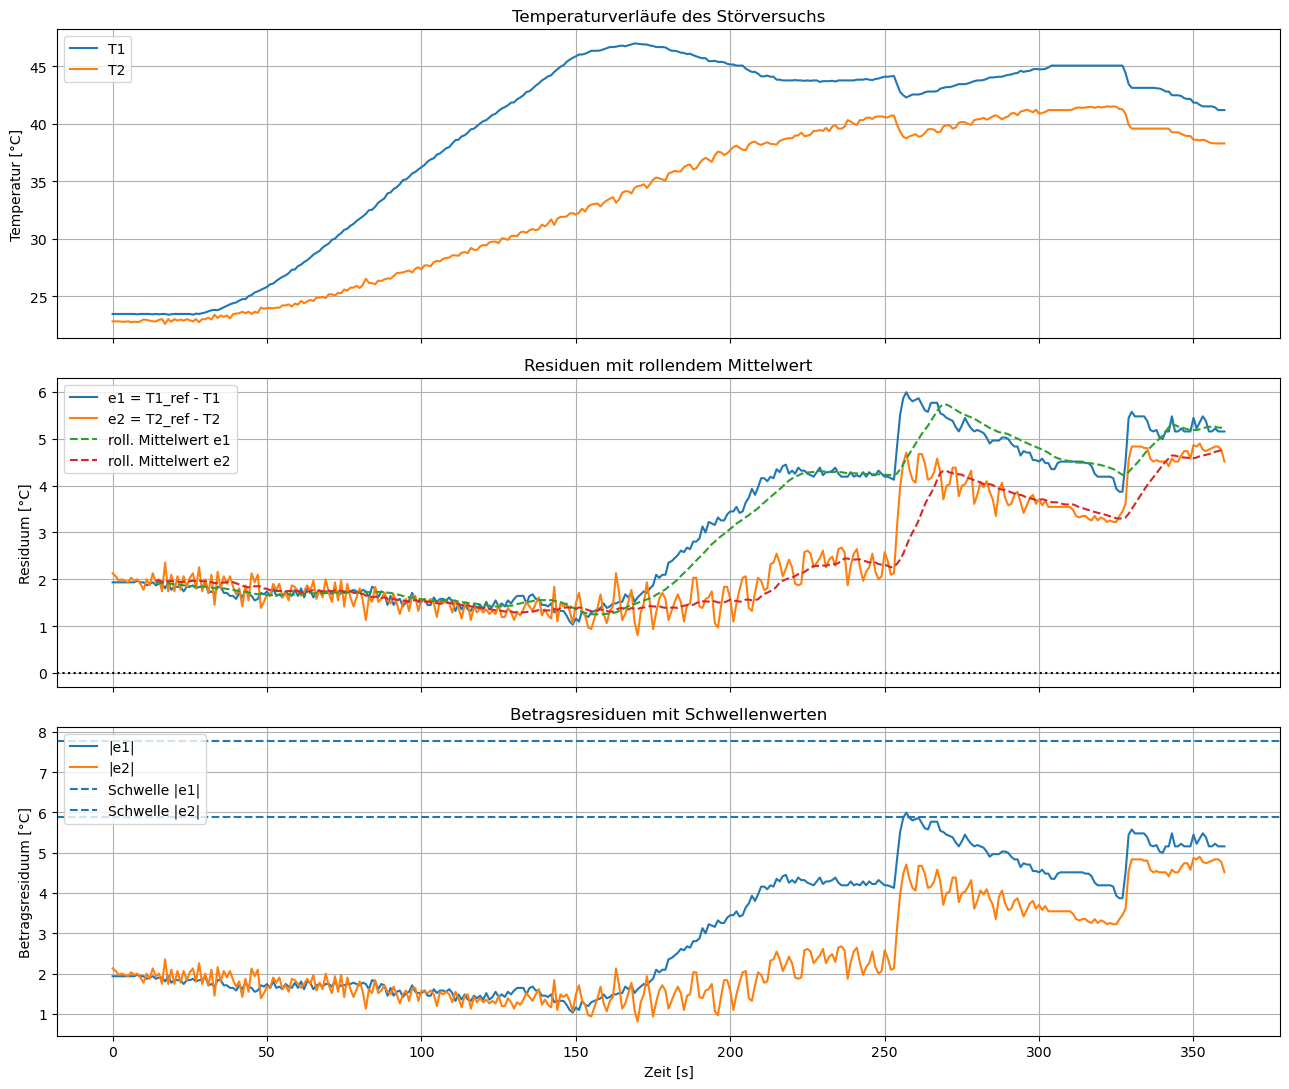

In [22]:

plot_detection_results(residual_df, baseline_stats)


## Kontrollkarten auf den Residuen

Nun werden die Residuen zusätzlich mit einer klassischen **XmR-Kontrollkarte** betrachtet.

Für diesen Grundversuch ist das sinnvoll, weil wir zeitlich geordnete Einzelwerte betrachten.
Die Kontrollkarten werden direkt auf den Residuen \(e_1(t)\) und \(e_2(t)\) angewendet.

### Bedeutung der Grenzlinien

Die gestrichelten Linien markieren die **statistischen Regelgrenzen** der Kontrollkarte:

- **CL (Center Line):** mittlere Lage des Prozesses
- **UCL (Upper Control Limit):** obere Regelgrenze
- **LCL (Lower Control Limit):** untere Regelgrenze

Liegt ein Punkt **außerhalb** dieser Grenzen, spricht das für eine **Sonderursache** oder eine
auffällige Prozessabweichung.

Bei der **Moving-Range-Darstellung** wird zusätzlich die Spannweite zwischen aufeinanderfolgenden
Werten betrachtet. Dort zeigt die obere Grenze, ab wann die kurzfristige Änderung ungewöhnlich groß ist.


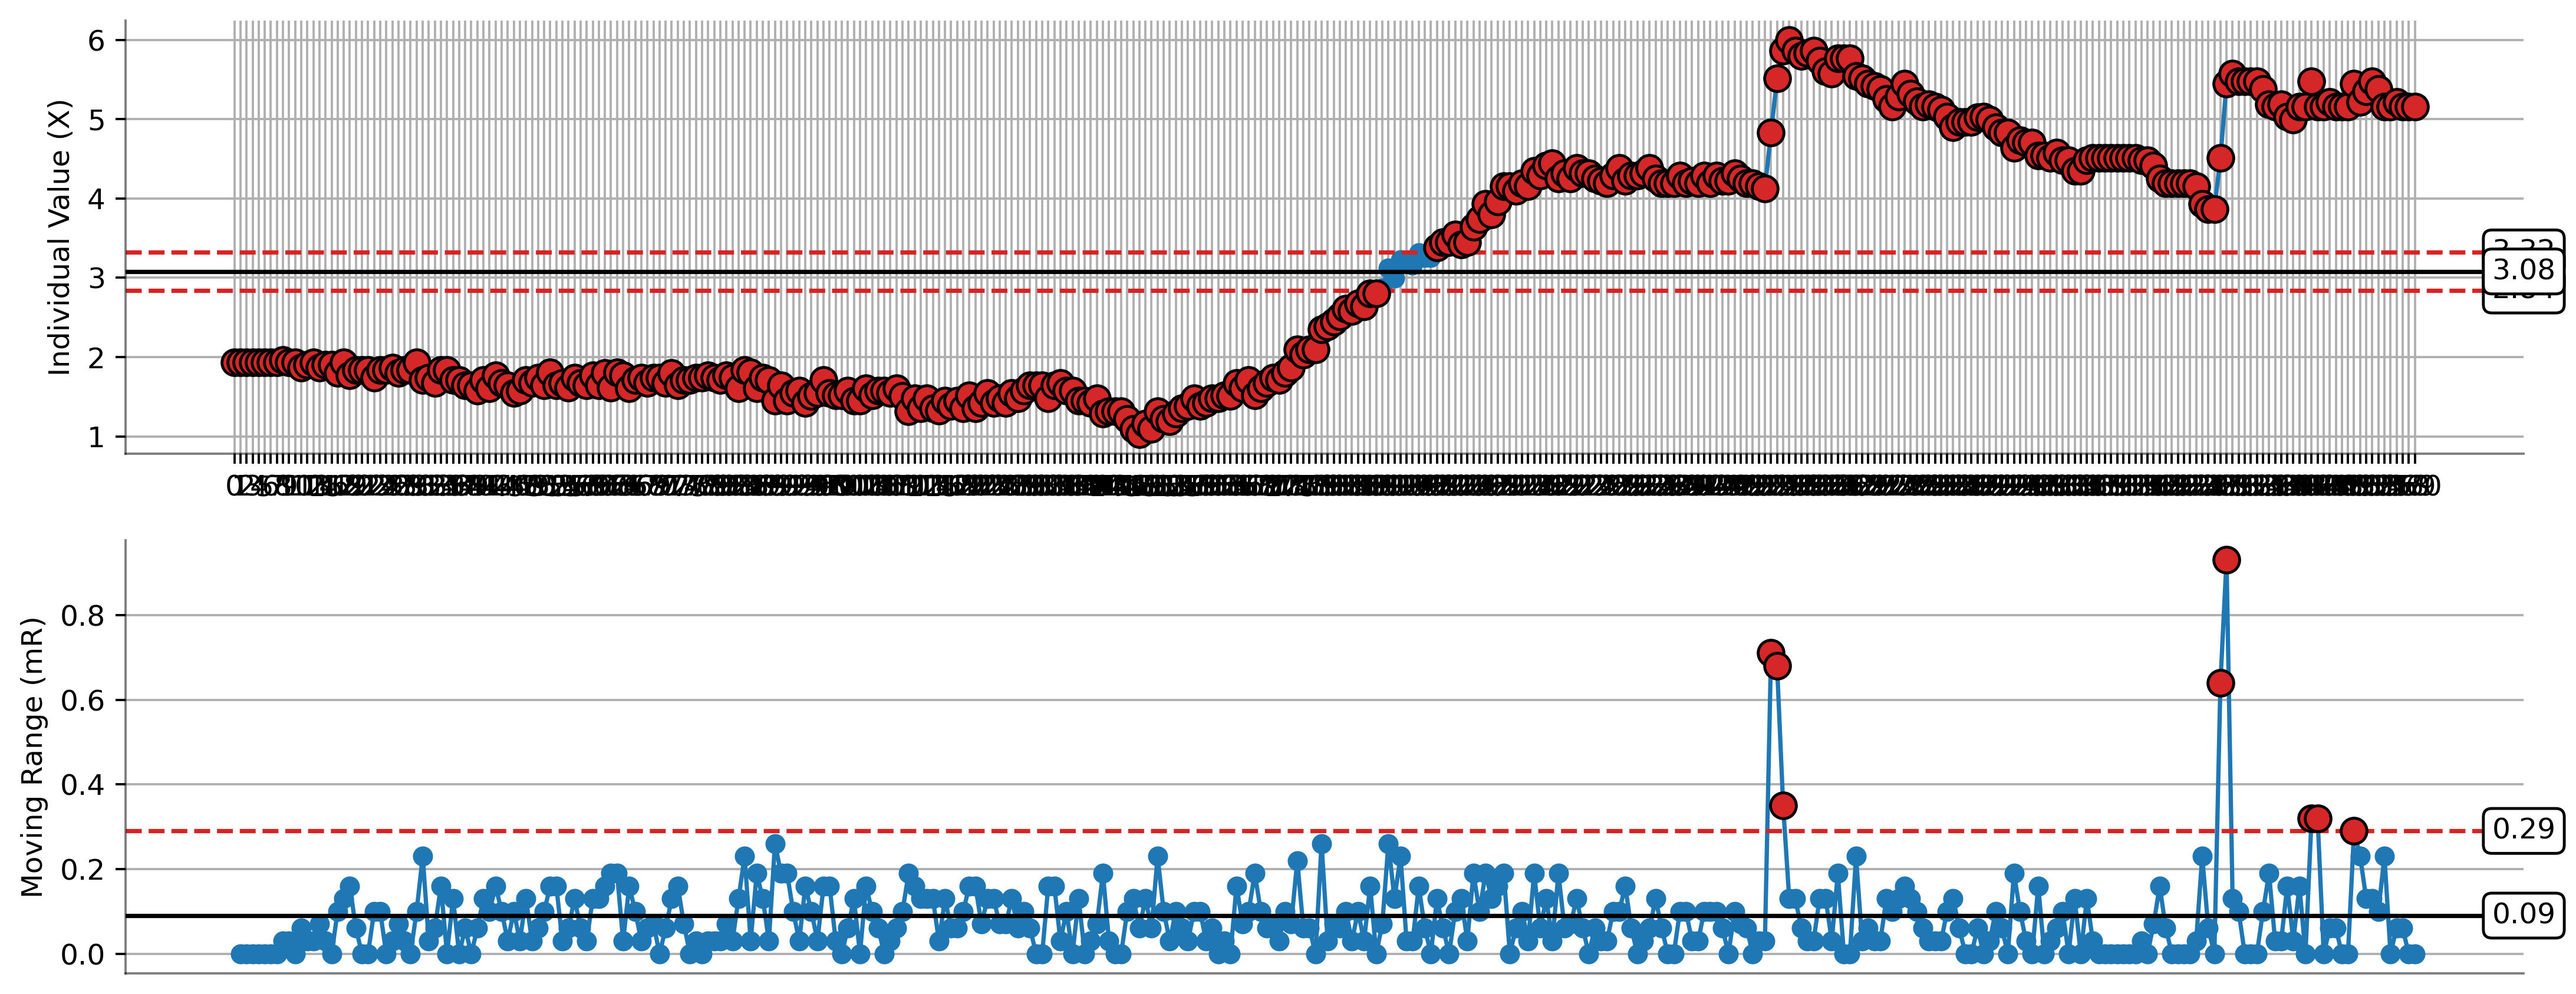

In [24]:

# XmR-Kontrollkarte für e1
xmr_result_e1 = run_xmr_chart(
    residual_df,
    value_col="e1",
    ylabel="Residuum e1 [°C]",
)


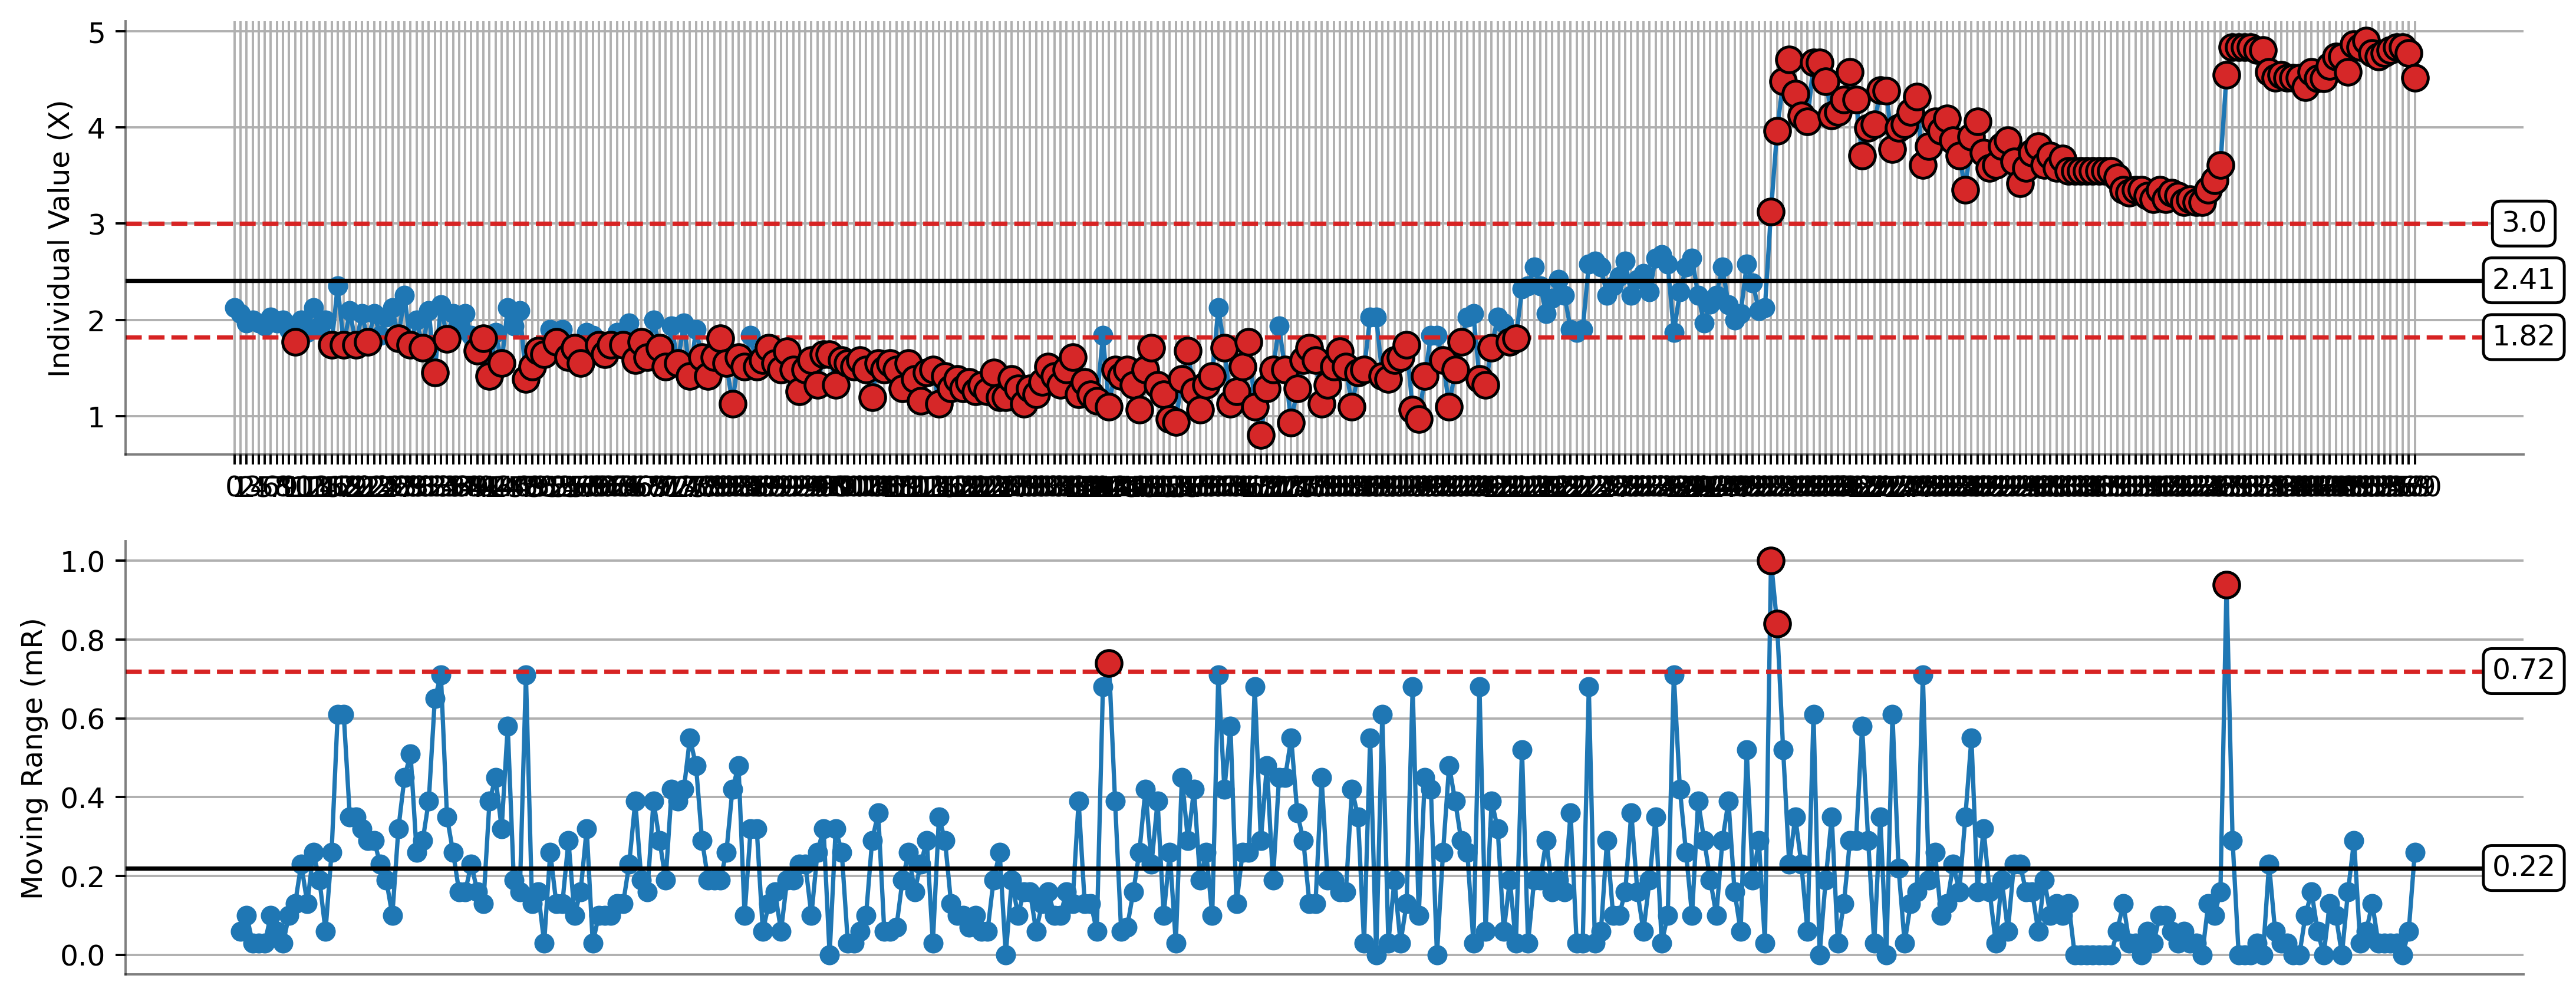

In [26]:

# XmR-Kontrollkarte für e2
xmr_result_e2 = run_xmr_chart(
    residual_df,
    value_col="e2",
    ylabel="Residuum e2 [°C]",
)


## Interpretation

Diskutieren Sie die folgenden Fragen:

1. In welchen Zeitbereichen unterscheiden sich Normalversuch und Störversuch besonders deutlich?
2. Reagiert \(T_1\) oder \(T_2\) stärker auf die eingebrachte Störung?
3. Welche Residuen \(e_1(t)\) oder \(e_2(t)\) sind für die Erkennung hilfreicher?
4. Welche Baseline-Methode ist in diesem Grundversuch am übersichtlichsten?
5. Stimmen die grafisch markierten Auffälligkeiten mit den von Ihnen eingebrachten Störungen überein?


In [36]:

# Daten speichern
output_dir = Path("TCLab_FDD_Baseline_exports")
output_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

normal_path = output_dir / f"TCLab_FDD_baseline_normal_run.csv"
disturbed_path = output_dir / f"TCLab_FDD_baseline_disturbed_run.csv"
residual_path = output_dir / f"TCLab_FDD_baseline_residual_analysis.csv"

normal_df.to_csv(normal_path, index=False)
disturbed_df.to_csv(disturbed_path, index=False)
residual_df.to_csv(residual_path, index=False)

print("Dateien gespeichert:")
print(normal_path)
print(disturbed_path)
print(residual_path)


Dateien gespeichert:
TCLab_FDD_Baseline_exports\TCLab_FDD_baseline_normal_run.csv
TCLab_FDD_Baseline_exports\TCLab_FDD_baseline_disturbed_run.csv
TCLab_FDD_Baseline_exports\TCLab_FDD_baseline_residual_analysis.csv


## Zusammenfassung

In diesem Notebook wurden:

- vorgegebene Heizleistungsprofile für \(Q_1(t)\) und \(Q_2(t)\) abgefahren
- Temperaturverläufe \(T_1(t)\) und \(T_2(t)\) live aufgezeichnet
- ein Normalversuch als Referenzlauf verwendet
- Residuen aus der Abweichung zwischen Referenzlauf und Störversuch gebildet
- Baseline-Methoden zur Anomalieerkennung angewendet:
  - Schwellenwert
  - rollender Mittelwert
  - XmR-Kontrollkarte

Damit ist eine erste Grundlage für Fault Detection mit dem TCLab geschaffen.
In späteren Notebooks können darauf komplexere Fahrweisen, automatische Feature-Extraktion und weiterführende Modelle aufbauen.
